In [18]:
# =============================================================================
# DIRECTIONAL VALIDATION: UCI BANK MARKETING DATASET
#
# PURPOSE:
# Does the two-layer qualification architecture — withholding a plausible
# post-scoring signal from the ML model and applying it through a tier-based
# qualification layer — produce directionally similar behaviour in a
# structurally different real-world dataset?
#
# This is directional robustness evidence, not a replication.
#
# CONTEXT:
# The UCI Bank Marketing dataset contains 41,188 records from outbound
# telemarketing campaigns by a Portuguese banking institution, predicting
# whether a client subscribes to a term deposit. Baseline subscription
# rate: ~11.3%.
#
# The constrained selection problem is structurally the same as the
# primary study: given a fixed number of calls a team can make (K),
# which clients should they call to maximise subscription rate?
#
# SOURCE: https://archive.ics.uci.edu/dataset/222/bank+marketing
# Reference: Moro et al. (2014), Decision Support Systems, Elsevier
#
# LEAKAGE:
# 'duration' (last contact duration in seconds) is excluded — it is only
# known after the call completes, at which point the outcome is also known.
# Documented in the UCI repository.
#
# VALIDATION DESIGN (single-tier, consistent with methodology):
#
#   H1 — Proxy eligibility filter:
#        pdays = 999 AND previous = 0 (never contacted, no prior
#        relationship). Unlike the primary study's H1 (legal contactability
#        constraint), this is a cold-lead filter — a business decision not
#        to pursue clients with zero relationship history.
#
#   P1 — Previous campaign success: poutcome = 'success'
#        Clients who subscribed in a prior campaign. This is the only
#        qualification signal retained because it is plausibly revealed
#        through prior operational interaction rather than static
#        campaign-entry metadata. Excluded from the ML model.
#
#   No P2: 'contact' (cellular/telephone) was considered but is recorded
#        at campaign setup and does not clearly satisfy the post-scoring
#        temporal separation criterion. It is retained as a model feature.
#        'campaign' (number of contacts) is also retained in the model.
#
#   Three systems: S1 (ML baseline), S2 (tier qualification), S3 (blend)
#   No bootstrap (directional validation only)
# =============================================================================

In [2]:

# =============================================================================
# CELL BM-00 — SETUP
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
# Upload bank-additional-full.csv to this folder
# Download from: https://archive.ics.uci.edu/dataset/222/bank+marketing
DATA_FILE = DRIVE_PATH + 'bank-additional-full.csv'

print("Setup complete.")



Mounted at /content/drive
Setup complete.


In [3]:

# =============================================================================
# CELL BM-01 — LOAD DATA
# =============================================================================

# UCI Bank Marketing uses semicolon separator
df_raw = pd.read_csv(DATA_FILE, sep=';')

TARGET = 'y'

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nTarget value counts:\n{df_raw[TARGET].value_counts()}")
print(f"\nBaseline subscription rate: {(df_raw[TARGET] == 'yes').mean():.4f}")
print(f"\nSample rows:")
df_raw.head()



Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target value counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Baseline subscription rate: 0.1127

Sample rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:

# =============================================================================
# CELL BM-03 — PRE-PROCESSING
# =============================================================================

# Convert target to binary integer
df = df_raw.copy()
df[TARGET] = df[TARGET].map({'yes': 1, 'no': 0})

# Drop leakage and non-predictive columns
EXCLUDE_COLS = [
    'duration',      # leakage — only known post-call
    'y_binary',      # temporary column used for correlation check
]
df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns])

# Drop policy columns from model features (they go to policy_df only)
# They will be excluded formally in Cell BM-05

# Check for missing values
print(f"Shape after leakage removal: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nBaseline subscription rate: {df[TARGET].mean():.4f}")
print(f"Class distribution: {df[TARGET].value_counts().to_dict()}")



Shape after leakage removal: (41188, 20)
Missing values: 0
Duplicates: 1784

Baseline subscription rate: 0.1127
Class distribution: {0: 36548, 1: 4640}


In [6]:

# =============================================================================
# CELL BM-04 — TRAIN-TEST SPLIT
# =============================================================================

# Align policy_df to df index
policy_df_full = policy_df_full.loc[df.index].copy()
df             = df.reset_index(drop=True)
policy_df_full = policy_df_full.reset_index(drop=True)

assert len(df) == len(policy_df_full), "Alignment error"

y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X, y, policy_df_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train subscription rate: {y_train.mean():.4f}")
print(f"Test subscription rate:  {y_test.mean():.4f}")

BM_BASELINE_RATE    = y_test.mean()
BM_TOTAL_CONVERTERS = int(y_test.sum())
BM_K                = int(len(y_test) * 0.2)

print(f"\nBaseline rate : {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)")
print(f"Total subscribers in test: {BM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%)   : {BM_K:,}")


Train: (32950, 19)  |  Test: (8238, 19)
Train subscription rate: 0.1127
Test subscription rate:  0.1126

Baseline rate : 0.1126  (11.26%)
Total subscribers in test: 928
K (top 20%)   : 1,647


In [4]:
# =============================================================================
# CELL BM-02 — LEAKAGE REMOVAL AND POLICY COLUMN PRESERVATION
#
# LEAKAGE: 'duration' is excluded because it is only known after the call
# completes. Including it would leak post-outcome information into the model.
#
# POLICY COLUMNS are preserved before encoding. They are used for the
# eligibility filter and qualification layer, and are excluded from the ML model
# only where they are used as policy signals.
# =============================================================================

print("=== DURATION LEAKAGE CHECK ===")
df_raw["y_binary"] = (df_raw[TARGET] == "yes").astype(int)

print(f"Correlation of duration with outcome: {df_raw['duration'].corr(df_raw['y_binary']):.4f}")
print(f"Mean duration for subscribed: {df_raw[df_raw[TARGET] == 'yes']['duration'].mean():.0f}s")
print(f"Mean duration for not subscribed: {df_raw[df_raw[TARGET] == 'no']['duration'].mean():.0f}s")

print("""
Note:
'duration' is only known after the call completes. It is excluded from all
models because it would not be available at the point of pre-call selection.
""")

POLICY_COLUMNS = [
    "pdays",       # H1 proxy eligibility filter
    "previous",    # H1 proxy eligibility filter
    "poutcome",    # P1 qualification signal
]

policy_df_full = df_raw[POLICY_COLUMNS].copy()

print("Policy columns preserved:")
print(POLICY_COLUMNS)

print("\npoutcome values:")
print(df_raw["poutcome"].value_counts())

print("\npdays values summary:")
print(df_raw["pdays"].describe())

print("\nprevious values summary:")
print(df_raw["previous"].describe())



=== DURATION LEAKAGE CHECK ===
Correlation of duration with outcome: 0.4053
Mean duration for subscribed: 553s
Mean duration for not subscribed: 221s

Note:
'duration' is only known after the call completes. It is excluded from all
models because it would not be available at the point of pre-call selection.

Policy columns preserved:
['pdays', 'previous', 'poutcome']

poutcome values:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

pdays values summary:
count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

previous values summary:
count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

Important design decision:
'contact' is not used as P

In [7]:
# =============================================================================
# CELL BM-05 — PREPROCESSING PIPELINE
#
# Final model-exclusion logic:
# - duration is excluded as leakage.
# - pdays and previous are excluded because they form the H1 proxy eligibility filter.
# - poutcome is excluded because it is the P1 qualification signal.
# - campaign is INCLUDED in the model because H2 was removed.
# - contact is INCLUDED in the model because it is no longer used as P2.
# =============================================================================

MODEL_EXCLUDE = [
    "duration",    # leakage — only known after call completion
    "pdays",       # H1 proxy eligibility filter
    "previous",    # H1 proxy eligibility filter
    "poutcome",    # P1 qualification signal
]

X_train_model = X_train.drop(columns=[c for c in MODEL_EXCLUDE if c in X_train.columns])
X_test_model  = X_test.drop(columns=[c for c in MODEL_EXCLUDE if c in X_test.columns])

numeric_features = X_train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=["object"]).columns.tolist()

print(f"Excluded from model ({len(MODEL_EXCLUDE)}): {MODEL_EXCLUDE}")
print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Total model features: {len(numeric_features) + len(categorical_features)}")

print("""
Model-inclusion note:
'campaign' and 'contact' are now retained as ML features. They are not used
as qualification-layer signals because they do not satisfy the post-scoring
temporal separation criterion strongly enough.
""")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

Excluded from model (4): ['duration', 'pdays', 'previous', 'poutcome']

Numeric features (7): ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week']
Total model features: 16

Model-inclusion note:
'campaign' and 'contact' are now retained as ML features. They are not used
as qualification-layer signals because they do not satisfy the post-scoring
temporal separation criterion strongly enough.



In [8]:

# =============================================================================
# CELL BM-06 — TRAIN MODELS
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Class imbalance: scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f"Class imbalance ratio (neg/pos): {scale_pw:.1f}")
print(f"A model predicting all-zero achieves {(1-y_train.mean())*100:.1f}% accuracy — "
      f"accuracy is not a useful metric here.\n")

# Logistic Regression
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    )),
])
lr_search = GridSearchCV(
    lr_pipe, {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0,
)
lr_search.fit(X_train_model, y_train)
lr_auc = roc_auc_score(y_test, lr_search.predict_proba(X_test_model)[:, 1])
print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}  "
      f"(best C: {lr_search.best_params_['model__C']})")

# XGBoost
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=scale_pw,
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    {
        "model__n_estimators":     [100, 200, 300],
        "model__max_depth":        [2, 3, 4, 5],
        "model__learning_rate":    [0.01, 0.05, 0.1],
        "model__subsample":        [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_model, y_train)
xgb_auc = roc_auc_score(y_test, xgb_search.predict_proba(X_test_model)[:, 1])
print(f"XGBoost             AUC-ROC: {xgb_auc:.4f}  "
      f"(best params: {xgb_search.best_params_})")

# Compare with other studies
print(f"\n  X Education AUC:  0.8725  (primary study)")
print(f"  Stuffmart AUC:    0.9802  (synthetic — inflated)")
print(f"  Bank Marketing:   {xgb_auc:.4f}  (this study)")

# Select best model
if xgb_auc >= lr_auc:
    best_model, best_model_name, best_auc = xgb_search, "XGBoost", xgb_auc
else:
    best_model, best_model_name, best_auc = lr_search, "Logistic Regression", lr_auc

print(f"\nScoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})")

# Generate fixed ML probability vector
bm_ml_scores = best_model.predict_proba(X_test_model)[:, 1]



Class imbalance ratio (neg/pos): 7.9
A model predicting all-zero achieves 88.7% accuracy — accuracy is not a useful metric here.

Logistic Regression AUC-ROC: 0.7949  (best C: 0.1)
XGBoost             AUC-ROC: 0.8062  (best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0})

  X Education AUC:  0.8725  (primary study)
  Stuffmart AUC:    0.9802  (synthetic — inflated)
  Bank Marketing:   0.8062  (this study)

Scoring engine: XGBoost  (AUC-ROC: 0.8062)


In [16]:
# =============================================================================
# CELL BM-07 — BUILD RESULTS BASE AND COMPUTE POLICY FLAGS
#
# Final Bank Marketing validation architecture:
#
# H1 — proxy eligibility filter:
#   customers with no prior relationship/contact history are treated as outside
#   the operationally qualified pool. This is a proxy eligibility filter, not
#   a legal contactability rule.
#
# P1 — previous campaign success:
#   poutcome = 'success'. This is the only qualification signal retained because
#   it is plausibly revealed through prior operational interaction rather than
#   static campaign-entry metadata.
#
# =============================================================================

bm_results = policy_test.copy().reset_index(drop=True)
bm_results["actual"] = y_test.values
bm_results["ml_score"] = bm_ml_scores

# Robustly detect the "not previously contacted" pdays code.
# Some Bank Marketing versions use 999; some transformed versions may use -1.
if (bm_results["pdays"] == 999).any():
    BM_NO_PRIOR_PDAYS_VALUE = 999
elif (bm_results["pdays"] == -1).any():
    BM_NO_PRIOR_PDAYS_VALUE = -1
else:
    BM_NO_PRIOR_PDAYS_VALUE = bm_results["pdays"].max()

# H1: proxy eligibility filter — no prior relationship/contact history
bm_results["h1_flag"] = (
    bm_results["pdays"].eq(BM_NO_PRIOR_PDAYS_VALUE) &
    bm_results["previous"].eq(0)
)

# P1: previous campaign success
bm_results["p1_flag"] = bm_results["poutcome"].eq("success")


# Training-derived signal score for S3 calibrated blend.
# Use training data only to avoid deriving the signal score from the test set.
bm_signal_train = policy_train.copy().reset_index(drop=True)
bm_signal_train["actual"] = y_train.values

BM_POUTCOME_SIGNAL_MAP = (
    bm_signal_train
    .groupby("poutcome")["actual"]
    .mean()
    .to_dict()
)

BM_DEFAULT_SIGNAL_SCORE = y_train.mean()
BM_BASELINE_RATE_CUTOFF = BM_BASELINE_RATE

bm_results["signal_score"] = (
    bm_results["poutcome"]
    .map(BM_POUTCOME_SIGNAL_MAP)
    .fillna(BM_DEFAULT_SIGNAL_SCORE)
)

print("=== BANK MARKETING RESULTS BASE ===")
print(f"Total test records:         {len(bm_results):,}")
print(f"Baseline rate:              {BM_BASELINE_RATE:.4f} ({BM_BASELINE_RATE * 100:.2f}%)")
print(f"Total subscribers:          {BM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%):                {BM_K:,}")

print(f"\nH1 proxy eligibility filter:")
print(f"  pdays code used for no prior contact: {BM_NO_PRIOR_PDAYS_VALUE}")
print(f"  H1 flagged records: {bm_results['h1_flag'].sum():,} ({bm_results['h1_flag'].mean() * 100:.1f}%)")

print(f"\nP1 qualification signal:")
print(f"  poutcome = success: {bm_results['p1_flag'].sum():,} ({bm_results['p1_flag'].mean() * 100:.1f}%)")


print("\nTraining-derived poutcome signal map:")
print(BM_POUTCOME_SIGNAL_MAP)

contactable = bm_results[~bm_results["h1_flag"]].copy()
p1_eligible = contactable[
    contactable["p1_flag"] &
    (contactable["ml_score"] >= BM_BASELINE_RATE_CUTOFF)
]

print(f"\nContactable / eligible pool after H1: {len(contactable):,}")
print(f"P1 leads above baseline ML cutoff: {len(p1_eligible):,}")

=== BANK MARKETING RESULTS BASE ===
Total test records:         8,238
Baseline rate:              0.1126 (11.26%)
Total subscribers:          928
K (top 20%):                1,647

H1 proxy eligibility filter:
  pdays code used for no prior contact: 999
  H1 flagged records: 7,147 (86.8%)

P1 qualification signal:
  poutcome = success: 268 (3.3%)

Training-derived poutcome signal map:
{'failure': 0.14406532516768739, 'nonexistent': 0.08801379504504504, 'success': 0.648868778280543}

Contactable / eligible pool after H1: 1,091
P1 leads above baseline ML cutoff: 268


In [10]:
# =============================================================================
# CELL BM-08 — APPLY THREE SYSTEMS
#
# Final Bank Marketing validation architecture:
#
# S1 — ML baseline
#      ML ranking after H1 proxy eligibility filter.
#
# S2 — Tier qualification
#      H1-filtered pool + one qualification tier:
#      P1 = poutcome = success.
#      P1 leads are elevated only if their ML score is at or above the
#      baseline conversion rate.
#
# S3 — Calibrated blend
#      H1-filtered pool + blended score:
#      90% ML score + 10% training-derived poutcome signal score.
#
# This is directional validation only, not a replication of the primary study.
# =============================================================================

BM_TIER_CAP_FRACTION = 0.40
BM_BLEND_WEIGHT = 0.90

def apply_bm_systems(
    df,
    tier_cap_fraction=BM_TIER_CAP_FRACTION,
    blend_weight=BM_BLEND_WEIGHT,
    baseline_cutoff=BM_BASELINE_RATE_CUTOFF,
    k_fraction=0.20,
    verbose=False,
):
    out = df.copy()
    K = int(len(out) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    # H1 proxy eligibility filter
    out["hard_disqualified"] = out["h1_flag"]

    contactable = out[~out["hard_disqualified"]].copy()

    # S2 priority tiers: one qualification tier only
    contactable["priority_tier"] = 2
    contactable.loc[contactable["p1_flag"], "priority_tier"] = 1

    # Baseline cutoff: only elevate P1 if ML score also supports the lead
    below_cutoff = contactable["ml_score"] < baseline_cutoff
    contactable.loc[
        below_cutoff & contactable["priority_tier"].eq(1),
        "priority_tier"
    ] = 2

    # S3 calibrated blend
    contactable["blended_score"] = (
        blend_weight * contactable["ml_score"]
        + (1 - blend_weight) * contactable["signal_score"]
    )

    def build_tiercapped_ranking(pool):
        p1 = pool[pool["priority_tier"] == 1].sort_values("ml_score", ascending=False)
        rest = pool[pool["priority_tier"] == 2].sort_values("ml_score", ascending=False)

        selected_p1 = p1.head(tier_cap)

        overflow = pd.concat(
            [p1.iloc[tier_cap:], rest],
            ignore_index=True
        ).sort_values("ml_score", ascending=False)

        return pd.concat([selected_p1, overflow], ignore_index=True)

    if verbose:
        p1_count = (contactable["priority_tier"] == 1).sum()
        rest_count = (contactable["priority_tier"] == 2).sum()
        p1_tsr = p1_count / max(K, 1)

        print("\n=== BANK MARKETING SYSTEM DIAGNOSTICS ===")
        print(f"K={K:,}")
        print(f"Tier cap={tier_cap:,} ({tier_cap_fraction:.0%} of K)")
        print(f"Blend weight={blend_weight:.2f}")
        print(f"Baseline cutoff: ml_score >= {baseline_cutoff:.4f}")

        print(f"\nH1 proxy eligibility filter removed: {out['hard_disqualified'].sum():,}")
        print(f"Eligible pool: {len(contactable):,}")

        print("\nS2 tiers after baseline cutoff:")
        print(f"  P1 poutcome=success: {p1_count:,}")
        print(f"  General ML pool:      {rest_count:,}")

        print(f"\nP1 TSR: {p1_tsr:.2f}")
        print("Note: Bank Marketing validation uses one defensible qualification tier only.")

    return {
        "System 1 — ML baseline":
            contactable.sort_values("ml_score", ascending=False),

        "System 2 — Tier qualification":
            build_tiercapped_ranking(contactable),

        "System 3 — Calibrated blend":
            contactable.sort_values("blended_score", ascending=False),
    }

bm_systems = apply_bm_systems(bm_results, k_fraction=0.20, verbose=True)
print("\nBank Marketing systems applied.")


=== BANK MARKETING SYSTEM DIAGNOSTICS ===
K=1,647
Tier cap=658 (40% of K)
Blend weight=0.90
Baseline cutoff: ml_score >= 0.1126

H1 proxy eligibility filter removed: 7,147
Eligible pool: 1,091

S2 tiers after baseline cutoff:
  P1 poutcome=success: 268
  General ML pool:      823

P1 TSR: 0.16
Note: Bank Marketing validation uses one defensible qualification tier only.

Bank Marketing systems applied.


In [11]:
# =============================================================================
# CELL BM-09 — EVALUATE SYSTEMS
# =============================================================================

def evaluate_bm_systems(systems, k_fraction=0.20):
    K = int(len(bm_results) * k_fraction)

    rows = []
    for name, ranked_df in systems.items():
        selected = ranked_df.head(K)

        precision = selected["actual"].mean()
        recall = selected["actual"].sum() / BM_TOTAL_CONVERTERS
        lift = precision / BM_BASELINE_RATE
        wasted = 1 - precision

        rows.append({
            "system": name,
            "K": K,
            "eligible_leads": len(ranked_df),
            "converters_in_K": int(selected["actual"].sum()),
            "precision_at_k": round(precision, 4),
            "recall_at_k": round(recall, 4),
            "lift_at_k": round(lift, 4),
            "wasted_effort_rate": round(wasted, 4),
        })

    return pd.DataFrame(rows)

bm_main_results = evaluate_bm_systems(bm_systems, k_fraction=0.20)

print("=== BANK MARKETING — SYSTEM COMPARISON (K=20%) ===")
print(
    bm_main_results[
        [
            "system",
            "eligible_leads",
            "converters_in_K",
            "precision_at_k",
            "lift_at_k",
            "wasted_effort_rate",
        ]
    ].to_string(index=False)
)

s1_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 1 — ML baseline",
    "precision_at_k"
].iloc[0]

s2_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 2 — Tier qualification",
    "precision_at_k"
].iloc[0]

s3_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 3 — Calibrated blend",
    "precision_at_k"
].iloc[0]

print(f"""
=== PRIMARY FINDINGS ===

  S1  (ML baseline):              {s1_bm * 100:.1f}%
  S2  (tier qualification):       {s2_bm * 100:.1f}%  ({(s2_bm - s1_bm) * 100:+.1f} pp vs S1)
  S3  (calibrated blend):         {s3_bm * 100:.1f}%  ({(s3_bm - s1_bm) * 100:+.1f} pp vs S1)

  S2 vs S1: {(s2_bm - s1_bm) * 100:+.1f} pp
  {"✓ S2 outperforms S1 — directionally consistent with the primary mechanism." if s2_bm > s1_bm
   else "✗ S2 underperforms S1 — qualification reduces precision in this context."
   if s2_bm < s1_bm else "~ S2 = S1 — qualification is neutral in this context."}
""")

bm_main_results.to_csv("table_BM_main_results.csv", index=False)
print("Exported: table_BM_main_results.csv")

=== BANK MARKETING — SYSTEM COMPARISON (K=20%) ===
                       system  eligible_leads  converters_in_K  precision_at_k  lift_at_k  wasted_effort_rate
       System 1 — ML baseline            1091              288           0.264     2.3434               0.736
System 2 — Tier qualification            1091              288           0.264     2.3434               0.736
  System 3 — Calibrated blend            1091              288           0.264     2.3434               0.736

=== PRIMARY FINDINGS ===

  S1  (ML baseline):              26.4%
  S2  (tier qualification):       26.4%  (+0.0 pp vs S1)
  S3  (calibrated blend):         26.4%  (+0.0 pp vs S1)

  S2 vs S1: +0.0 pp
  ~ S2 = S1 — qualification is neutral in this context.

Exported: table_BM_main_results.csv


In [12]:
# =============================================================================
# CELL BM-10 — SENSITIVITY ANALYSIS
# =============================================================================

bm_k_rows = []

for k_frac in [0.10, 0.20, 0.30]:
    sys_run = apply_bm_systems(
        bm_results,
        tier_cap_fraction=BM_TIER_CAP_FRACTION,
        blend_weight=BM_BLEND_WEIGHT,
        k_fraction=k_frac,
        verbose=False,
    )

    eval_df = evaluate_bm_systems(sys_run, k_fraction=k_frac)
    eval_df["k_fraction"] = k_frac
    bm_k_rows.append(eval_df)

bm_k_results = pd.concat(bm_k_rows, ignore_index=True)

bm_k_pivot = bm_k_results.pivot_table(
    index="k_fraction",
    columns="system",
    values="precision_at_k",
).round(4)

print("=== K SENSITIVITY — Precision@K ===")
print(bm_k_pivot.to_string())

bm_cap_rows = []

for cap in [0.20, 0.40, 0.60, 1.00]:
    sys_run = apply_bm_systems(
        bm_results,
        tier_cap_fraction=cap,
        blend_weight=BM_BLEND_WEIGHT,
        k_fraction=0.20,
        verbose=False,
    )

    eval_df = evaluate_bm_systems(sys_run, k_fraction=0.20)
    eval_df["tier_cap_fraction"] = cap
    bm_cap_rows.append(eval_df)

bm_cap_results = pd.concat(bm_cap_rows, ignore_index=True)

bm_cap_pivot = bm_cap_results.pivot_table(
    index="tier_cap_fraction",
    columns="system",
    values="precision_at_k",
).round(4)

print("\n=== TIER CAP SENSITIVITY — Precision@K ===")
print("System 2 is subject to the tier cap. System 3 has no hard tiers.")
print(bm_cap_pivot.to_string())

bm_blend_rows = []

for weight in [0.80, 0.90, 0.95]:
    sys_run = apply_bm_systems(
        bm_results,
        tier_cap_fraction=BM_TIER_CAP_FRACTION,
        blend_weight=weight,
        k_fraction=0.20,
        verbose=False,
    )

    eval_df = evaluate_bm_systems(sys_run, k_fraction=0.20)
    eval_df["blend_weight"] = weight
    bm_blend_rows.append(eval_df)

bm_blend_results = pd.concat(bm_blend_rows, ignore_index=True)

bm_blend_pivot = bm_blend_results.pivot_table(
    index="blend_weight",
    columns="system",
    values="precision_at_k",
).round(4)

print("\n=== BLEND WEIGHT SENSITIVITY — Precision@K ===")
print("Only System 3 should vary materially with blend weight.")
print(bm_blend_pivot.to_string())

bm_k_results.to_csv("table_BM_k_sensitivity.csv", index=False)
bm_cap_results.to_csv("table_BM_cap_sensitivity.csv", index=False)
bm_blend_results.to_csv("table_BM_blend_sensitivity.csv", index=False)

print("\nSensitivity tables exported.")

=== K SENSITIVITY — Precision@K ===
system      System 1 — ML baseline  System 2 — Tier qualification  System 3 — Calibrated blend
k_fraction                                                                                    
0.1                         0.3402                         0.3426                       0.3414
0.2                         0.2640                         0.2640                       0.2640
0.3                         0.2640                         0.2640                       0.2640

=== TIER CAP SENSITIVITY — Precision@K ===
System 2 is subject to the tier cap. System 3 has no hard tiers.
system             System 1 — ML baseline  System 2 — Tier qualification  System 3 — Calibrated blend
tier_cap_fraction                                                                                    
0.2                                 0.264                          0.264                        0.264
0.4                                 0.264                          0.264  

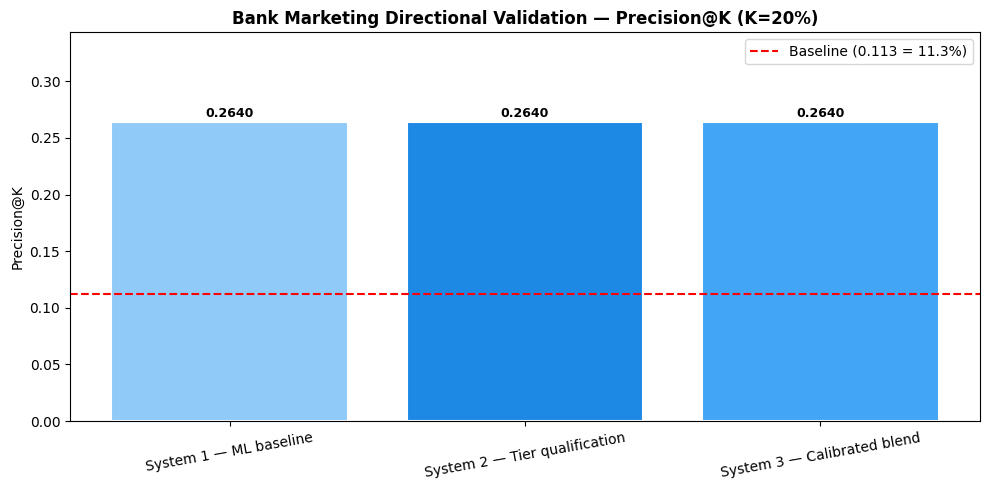

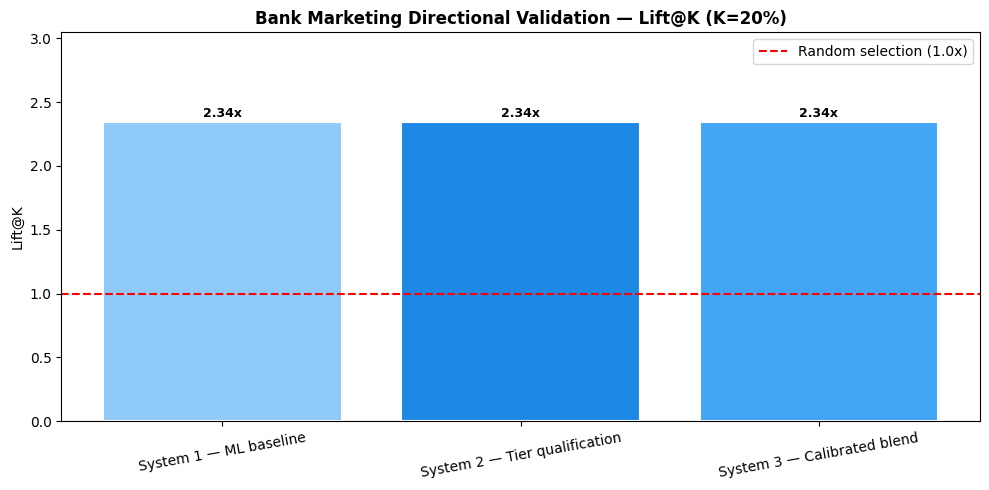

In [13]:
# =============================================================================
# CELL BM-11 — VISUALISATIONS
# =============================================================================

systems_order = [
    "System 1 — ML baseline",
    "System 2 — Tier qualification",
    "System 3 — Calibrated blend",
]

colors = ["#90CAF9", "#1E88E5", "#42A5F5"]

s1_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 1 — ML baseline",
    "precision_at_k"
].iloc[0]

s2_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 2 — Tier qualification",
    "precision_at_k"
].iloc[0]

s3_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 3 — Calibrated blend",
    "precision_at_k"
].iloc[0]

l1_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 1 — ML baseline",
    "lift_at_k"
].iloc[0]

l2_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 2 — Tier qualification",
    "lift_at_k"
].iloc[0]

l3_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 3 — Calibrated blend",
    "lift_at_k"
].iloc[0]

# --- BM-11a. Main Precision@K ---
fig, ax = plt.subplots(figsize=(10, 5))

prec_vals = [s1_bm, s2_bm, s3_bm]

bars = ax.bar(
    systems_order,
    prec_vals,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
)

ax.axhline(
    BM_BASELINE_RATE,
    color="red",
    linestyle="--",
    label=f"Baseline ({BM_BASELINE_RATE:.3f} = {BM_BASELINE_RATE * 100:.1f}%)",
)

for bar, val in zip(bars, prec_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Bank Marketing Directional Validation — Precision@K (K=20%)",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel("Precision@K")
ax.set_ylim(0, max(prec_vals) * 1.3)
ax.tick_params(axis="x", rotation=10)
ax.legend()

plt.tight_layout()
plt.savefig("fig_BM_01_precision_comparison.png", dpi=150)
plt.show()

# --- BM-11b. Lift@K ---
fig, ax = plt.subplots(figsize=(10, 5))

lift_vals = [l1_bm, l2_bm, l3_bm]

bars = ax.bar(
    systems_order,
    lift_vals,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
)

ax.axhline(
    1.0,
    color="red",
    linestyle="--",
    label="Random selection (1.0x)",
)

for bar, val in zip(bars, lift_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}x",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Bank Marketing Directional Validation — Lift@K (K=20%)",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel("Lift@K")
ax.set_ylim(0, max(lift_vals) * 1.3)
ax.tick_params(axis="x", rotation=10)
ax.legend()

plt.tight_layout()
plt.savefig("fig_BM_02_lift_comparison.png", dpi=150)
plt.show()

In [17]:
# =============================================================================
# CELL BM-12 — INTERPRETATION
# =============================================================================

s1_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 1 — ML baseline",
    "precision_at_k"
].iloc[0]

s2_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 2 — Tier qualification",
    "precision_at_k"
].iloc[0]

s3_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 3 — Calibrated blend",
    "precision_at_k"
].iloc[0]

l1_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 1 — ML baseline",
    "lift_at_k"
].iloc[0]

l2_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 2 — Tier qualification",
    "lift_at_k"
].iloc[0]

l3_bm = bm_main_results.loc[
    bm_main_results["system"] == "System 3 — Calibrated blend",
    "lift_at_k"
].iloc[0]

def fmt(x):
    return f"{x * 100:.1f}%"

def gap(a, b):
    return f"{(a - b) * 100:+.1f} pp"

s2_beats_s1 = s2_bm > s1_bm
s3_beats_s1 = s3_bm > s1_bm

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║        BANK MARKETING DIRECTIONAL VALIDATION INTERPRETATION                ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET AND METHODOLOGY

  Dataset       : UCI Bank Marketing
  Context       : Outbound telemarketing campaign selection
  Test set      : {len(bm_results):,} records
  K             : {BM_K:,}
  Baseline rate : {BM_BASELINE_RATE:.4f} ({BM_BASELINE_RATE * 100:.2f}%)
  Scoring engine: {best_model_name} (AUC-ROC: {best_auc:.4f})

  Final validation design:
    H1: pdays={BM_NO_PRIOR_PDAYS_VALUE} AND previous=0
        Proxy eligibility filter for no prior relationship/contact history.
    P1: poutcome='success'
        Previous campaign success; retained as the only defensible
        post-scoring qualification signal.
    campaign:
        retained in the ML model because H2 was removed and campaign intensity
        is predictive information available to the model.

MAIN RESULTS AT K=20%

  S1 — ML baseline:          {fmt(s1_bm)}  Lift={l1_bm:.2f}x
  S2 — Tier qualification:   {fmt(s2_bm)}  Lift={l2_bm:.2f}x  ({gap(s2_bm, s1_bm)} vs S1)
  S3 — Calibrated blend:     {fmt(s3_bm)}  Lift={l3_bm:.2f}x  ({gap(s3_bm, s1_bm)} vs S1)
  Baseline random selection: {fmt(BM_BASELINE_RATE)}  Lift=1.00x

DIRECTIONAL FINDING

  S2 vs S1: {gap(s2_bm, s1_bm)}

  {"S2 outperforms S1 in point estimate, giving directional support for the two-layer qualification mechanism in this outbound context." if s2_beats_s1
   else "S2 underperforms S1 in this context, suggesting that the qualification mechanism is sensitive to dataset context and proxy-signal quality."
   if s2_bm < s1_bm else "S2 equals S1 in this context, suggesting a neutral directional result."}

SCOPE OF CONCLUSION

  This validation is not a replication of the primary study. The Bank Marketing
  dataset is real operational data, but it represents outbound campaign
  selection rather than inbound lead qualification. It also contains only one
  defensible post-scoring qualification signal: poutcome='success'.

  The purpose of this notebook is therefore narrower: it checks whether the
  same architecture — withholding a plausible post-scoring signal from the ML
  model and applying it through a qualification layer — produces directionally
  similar behaviour in a different real-world dataset.

  Results should be reported as directional robustness evidence, not as
  independent confirmation of the primary study.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║        BANK MARKETING DIRECTIONAL VALIDATION INTERPRETATION                ║
╚══════════════════════════════════════════════════════════════════════════════╝

DATASET AND METHODOLOGY

  Dataset       : UCI Bank Marketing
  Context       : Outbound telemarketing campaign selection
  Test set      : 8,238 records
  K             : 1,647
  Baseline rate : 0.1126 (11.26%)
  Scoring engine: XGBoost (AUC-ROC: 0.8062)

  Final validation design:
    H1: pdays=999 AND previous=0
        Proxy eligibility filter for no prior relationship/contact history.
    P1: poutcome='success'
        Previous campaign success; retained as the only defensible
        post-scoring qualification signal.
    campaign:
        retained in the ML model because H2 was removed and campaign intensity
        is predictive information available to the model.

MAIN RESULTS AT K=20%

  S1 — ML baseline:          26.4%  Lift=2.34x
  S2 

End